# Event 01 — COVID 대폭락 & Fed 무제한 QE
## 스토리텔링 차트 (Scrollytelling Stepper)

### 4가지 디자인 원칙
1. **점진적 공개 (Stepper)** — 프롤로그부터 Act 5까지 시간 순서대로 한 프레임씩 공개
2. **축 분리 (No Dual-Axis)** — 주가 / 공포 지수 / 중앙은행 자산을 각각 별도 패널로 분리
3. **하이라이트 & 디밍** — 활성 국면만 진한 색, 나머지는 회색으로 흐리게 처리해 시선 유도
4. **용어 순화** — VIX → *시장 공포 지수*, 무제한 QE → *무제한 돈 풀기*, 서킷 → *거래 일시중단*, 50bp → *-0.5%p*

### 출력
- `data/figures/e01_story/00_prologue.png` … `05_act5.png` — 스토리 프레임 6장
- `data/figures/e01_story/99_summary.png` — 전체 종합 1장

## 1. Imports & 경로 설정

In [16]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

ROOT = Path(os.getcwd()).parent
EVENT_PATH = ROOT / 'data' / 'processed' / 'event_01_covid_crash.csv'
FED_PATH   = ROOT / 'data' / 'raw' / 'FedAssets.csv'
FIG_DIR    = ROOT / 'data' / 'figures' / 'e01_story'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f'ROOT     : {ROOT}')
print(f'FIG_DIR  : {FIG_DIR}')

ROOT     : c:\Users\kimch\Desktop\project\pandemic-finance
FIG_DIR  : c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\e01_story


## 2. 데이터 로드

In [17]:
event = pd.read_csv(EVENT_PATH, index_col=0, parse_dates=True)
fed = pd.read_csv(FED_PATH, index_col=0, parse_dates=True)
fed_window = fed.loc['2020-02-01':'2020-04-30'].copy()
fed_window['WALCL_T'] = fed_window['WALCL'] / 1e6  # $ Trillions

print(f'event      : {event.shape}, {event.index.min().date()} ~ {event.index.max().date()}')
print(f'fed_window : {fed_window.shape}')
event.head(3)

event      : (43, 3), 2020-02-17 ~ 2020-04-15
fed_window : (13, 2)


,SP500,VIX,days_from_event
2020-02-17,3380.16,13.68,-28
2020-02-18,3370.29,14.83,-27
2020-02-19,3386.15,14.38,-26


## 3. 5국면 정의 

각 국면마다:
- `narrative` — 프레임 상단에 표시될 한 줄 스토리
- `hero_annotations` — 해당 국면에서만 표시될 주석 (활성 프레임에서만 노출)

In [18]:
phases = [
    {
        'id': 'prologue', 'name': 'Prologue — 무관심',
        'start': '2020-02-17', 'end': '2020-02-19', 'color': '#64B5F6',
        'narrative': '전염병은 "강 건너 불"이었다. 주가는 사상 최고치, 공포 지수는 14.4로 깊이 잠들어 있었다.',
        'hero_annotations': [
            ('2020-02-19', 'SP500', 3386.15, '사상 최고치\n3,386', (-60, 25), 'left'),
            ('2020-02-19', 'VIX',     14.38, '공포 지수 14.4\n(매우 평온)', (-60, 25), 'left'),
        ],
    },
    {
        'id': 'act1', 'name': 'Act 1 — 공포의 발아',
        'start': '2020-02-20', 'end': '2020-03-06', 'color': '#FFB74D',
        'narrative': '이탈리아 지역 감염 확산. 중앙은행이 긴급 금리 인하(-0.5%p)를 단행하자, 시장은 "Fed가 뭘 알고 있나?"는 공포로 반응했다.',
        'hero_annotations': [
            ('2020-03-03', 'SP500', 3003.37, '긴급 금리 인하\n(-0.5%p)', (-80, -40), 'left'),
            ('2020-03-06', 'VIX',     41.94, '공포 지수 3배 상승\n14 → 42', (10, 15), 'left'),
        ],
    },
    {
        'id': 'act2', 'name': 'Act 2 — 연쇄 거래중단',
        'start': '2020-03-09', 'end': '2020-03-13', 'color': '#E57373',
        'narrative': '역사상 유례없는 연쇄 거래 일시중단의 시작 — 1주일 새 두 번이나 거래가 멈췄다. WHO의 팬데믹 선언이 공포를 글로벌로 확산시켰고, 주식·채권·원유·비트코인이 동시에 무너졌다.',
        'hero_annotations': [
            ('2020-03-09', 'SP500', 2746.56, '거래 일시중단 #1\n(-7.6%)', (-95, 30), 'left'),
            ('2020-03-11', 'SP500', 2741.38, 'WHO\n팬데믹 공식 선언', (-45, 75), 'left'),
            ('2020-03-12', 'SP500', 2480.64, '거래 일시중단 #2\n(-9.5%)', (-10, -45), 'right'),
            ('2020-03-13', 'SP500', 2711.02, '미국\n국가비상사태 선포', (15, 30), 'left'),
            ('2020-03-12', 'VIX',     75.47, '공포 지수 75\n(2008 위기 수준)', (10, 5), 'left'),
        ],
    },
    {
        'id': 'act3', 'name': 'Act 3 — 공포 정점',
        'start': '2020-03-16', 'end': '2020-03-20', 'color': '#C62828',
        'narrative': '공포 지수 82.69 (종가 기준 사상 최고) — 2008 글로벌 금융위기 기록 경신. 이 기간 3·4번째 거래 일시중단(3/16, 3/18)이 이어졌고, 주말 제로금리(-1.0%p)와 7천억 달러 돈 풀기도 공포를 잡지 못했다.',
        'hero_annotations': [
            ('2020-03-16', 'VIX',     82.69, '공포 지수 82.69\n(종가 기준 사상 최고)', (25, -5), 'left'),
            ('2020-03-16', 'SP500', 2386.13, '주가 -12.0%\n1987년 이후 최악', (25, 20), 'left'),
            ('2020-03-18', 'SP500', 2398.10, '거래 일시중단 #4', (10, -35), 'left'),
        ],
    },
    {
        'id': 'act4', 'name': 'Act 4 — 무제한 돈 풀기',
        'start': '2020-03-23', 'end': '2020-03-23', 'color': '#2E7D32',
        'narrative': '중앙은행의 "무제한 양적완화" 선언. 한도가 없는 돈 풀기 — 주가는 바로 이 날이 저점이었다. 하나의 발표가 모든 흐름을 뒤집었다.',
        'hero_annotations': [
            ('2020-03-23', 'SP500', 2237.40, '무제한 돈 풀기 선언\n→ 주가 저점', (25, -35), 'left'),
            ('2020-03-25', 'FED',      5.25, '1주일 +5,860억$\n(주간 역대 최대)', (-120, 15), 'left'),
        ],
    },
    {
        'id': 'act5', 'name': 'Act 5 — V자 반등',
        'start': '2020-03-24', 'end': '2020-04-30', 'color': '#66BB6A',
        'narrative': '15거래일 만에 +27% 반등. V자 회복의 대가는 2년 뒤 40년래 최악의 인플레이션으로 되돌아온다.',
        'hero_annotations': [
            ('2020-04-14', 'SP500', 2846.06, '+27% 반등\n(15거래일)', (-90, 25), 'left'),
            ('2020-04-22', 'FED',      6.57, '중앙은행 자산\n+$2.4조 (4주)', (-130, -25), 'left'),
        ],
    },
]

pd.DataFrame([{k: v for k, v in p.items() if k != 'hero_annotations'} for p in phases])

,id,name,start,end,color,narrative
0,prologue,Prologue — 무관심,2020-02-17,2020-02-19,#64B5F6,"전염병은 ""강 건너 불""이었다. 주가는 사상 최고치, 공포 지수는 14.4로 깊이 ..."
1,act1,Act 1 — 공포의 발아,2020-02-20,2020-03-06,#FFB74D,"이탈리아 지역 감염 확산. 중앙은행이 긴급 금리 인하(-0.5%p)를 단행하자, 시..."
2,act2,Act 2 — 연쇄 거래중단,2020-03-09,2020-03-13,#E57373,역사상 유례없는 연쇄 거래 일시중단의 시작 — 1주일 새 두 번이나 거래가 멈췄다....
3,act3,Act 3 — 공포 정점,2020-03-16,2020-03-20,#C62828,공포 지수 82.69 (종가 기준 사상 최고) — 2008 글로벌 금융위기 기록 경...
4,act4,Act 4 — 무제한 돈 풀기,2020-03-23,2020-03-23,#2E7D32,"중앙은행의 ""무제한 양적완화"" 선언. 한도가 없는 돈 풀기 — 주가는 바로 이 날이..."
5,act5,Act 5 — V자 반등,2020-03-24,2020-04-30,#66BB6A,15거래일 만에 +27% 반등. V자 회복의 대가는 2년 뒤 40년래 최악의 인플레...


## 4. 공통 상수 & 헬퍼 함수

- `plot_panel()` — 한 패널을 "전체 데이터는 회색으로 디밍 + 활성 구간만 진한 색으로 오버레이" 방식으로 그림
- `draw_frame()` — 4-panel 프레임 하나를 그리고 저장

In [19]:
# ---------- 고정 축 범위 (프레임 간 비교 가능) ----------
XLIM  = (pd.Timestamp('2020-02-17'), pd.Timestamp('2020-04-30'))
YLIM_SP  = (2100, 3500)
YLIM_VIX = (0, 95)
YLIM_FED = (3.9, 7.5)

LABELS = {
    'SP500': 'S&P 500 주가지수',
    'VIX':   '시장 공포 지수 (VIX)',
    'FED':   '중앙은행 자산 ($ 조 달러)',
}

DIM_COLOR = '#D0D0D0'

def plot_panel(ax, x, y, active_color, ylabel, visible_end, phase, fill=False, marker=None):
    """패널 하나 그리기 — 디밍된 전체선 + 활성 구간 오버레이."""
    # 1) visible_end 까지만 표시 (미래는 감춤)
    mask_visible = x <= visible_end
    xv, yv = x[mask_visible], y[mask_visible]

    # 2) 배경: 전체를 회색으로 디밍
    ax.plot(xv, yv, color=DIM_COLOR, lw=1.5, alpha=0.8, zorder=2)
    if fill:
        ax.fill_between(xv, yv, YLIM_VIX[0], color=DIM_COLOR, alpha=0.2, zorder=1)

    # 3) 활성 구간 오버레이 (진한 색)
    ps = pd.Timestamp(phase['start'])
    pe = pd.Timestamp(phase['end']) + pd.Timedelta(days=1)
    mask_active = (xv >= ps) & (xv <= pe)
    if mask_active.any():
        kwargs = dict(color=active_color, lw=3.2, zorder=5)
        if marker:
            kwargs.update(marker=marker, markersize=7, markerfacecolor=active_color,
                          markeredgecolor='white', markeredgewidth=1.5)
        ax.plot(xv[mask_active], yv[mask_active], **kwargs)
        if fill:
            ax.fill_between(xv[mask_active], yv[mask_active], YLIM_VIX[0],
                            color=active_color, alpha=0.3, zorder=3)

    ax.set_ylabel(ylabel, fontsize=10.5, fontweight='bold', color='#333')
    ax.tick_params(axis='y', labelsize=9)
    ax.grid(alpha=0.2, zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


def draw_frame(idx, show_future=False):
    """idx 번째 국면을 주인공으로 하는 프레임 생성 & 저장."""
    phase = phases[idx]
    phase_end = pd.Timestamp(phase['end'])
    visible_end = XLIM[1] if show_future else phase_end + pd.Timedelta(days=2)

    fig = plt.figure(figsize=(14, 11))
    gs = fig.add_gridspec(4, 1, height_ratios=[0.35, 1.4, 1.2, 1.2], hspace=0.18)
    ax_rib = fig.add_subplot(gs[0])
    ax_sp  = fig.add_subplot(gs[1], sharex=ax_rib)
    ax_vix = fig.add_subplot(gs[2], sharex=ax_rib)
    ax_fed = fig.add_subplot(gs[3], sharex=ax_rib)

    # ---- Ribbon: 활성 국면만 진하게 ----
    for i, p in enumerate(phases):
        s = pd.Timestamp(p['start'])
        e = pd.Timestamp(p['end'])
        if s == e:
            e = s + pd.Timedelta(days=1)
        active = (i == idx)
        ax_rib.axvspan(s, e, color=p['color'], alpha=0.95 if active else 0.18)
        short_name = p['name'].split('—')[1].strip() if '—' in p['name'] else p['name']
        ax_rib.text(s + (e - s) / 2, 0.5, short_name,
                    ha='center', va='center',
                    fontsize=10.5 if active else 9,
                    fontweight='bold' if active else 'normal',
                    color='#111' if active else '#AAA')
    ax_rib.set_xlim(XLIM); ax_rib.set_ylim(0, 1); ax_rib.set_yticks([])
    for s in ['top', 'right', 'bottom', 'left']:
        ax_rib.spines[s].set_visible(False)
    ax_rib.tick_params(bottom=False, labelbottom=False)

    # ---- 타이틀 & 서사 ----
    fig.suptitle(f'[{idx+1}/6]  {phase["name"]}',
                 fontsize=16, fontweight='bold', y=0.975, color='#111')
    fig.text(0.5, 0.935, phase['narrative'],
             ha='center', va='top', fontsize=11.5, color='#333',
             style='italic', wrap=True)

    # ---- 세 패널 ----
    plot_panel(ax_sp,  event.index, event['SP500'], phase['color'],
               LABELS['SP500'], visible_end, phase)
    plot_panel(ax_vix, event.index, event['VIX'], phase['color'],
               LABELS['VIX'], visible_end, phase, fill=True)
    plot_panel(ax_fed, fed_window.index, fed_window['WALCL_T'], phase['color'],
               LABELS['FED'], visible_end, phase, marker='o')

    ax_sp.set_ylim(YLIM_SP)
    ax_vix.set_ylim(YLIM_VIX)
    ax_fed.set_ylim(YLIM_FED)

    # ---- 무제한 QE 수직선 (Act 4 이후 프레임에서 강조) ----
    qe_date = pd.Timestamp('2020-03-23')
    if qe_date <= visible_end:
        alpha = 0.7 if idx >= 4 else 0.25
        for ax in (ax_sp, ax_vix, ax_fed):
            ax.axvline(qe_date, color='#2E7D32', linestyle=':', lw=1.5, alpha=alpha, zorder=2)

    # ---- Hero annotations (활성 국면만) ----
    axmap = {'SP500': ax_sp, 'VIX': ax_vix, 'FED': ax_fed}
    for date, target, y, text, (dx, dy), ha in phase['hero_annotations']:
        ax = axmap[target]
        d = pd.Timestamp(date)
        c = phase['color']
        ax.scatter([d], [y], s=85, color=c, zorder=6, edgecolors='white', lw=1.8)
        ax.annotate(text, xy=(d, y), xytext=(dx, dy),
                    textcoords='offset points', fontsize=10, fontweight='bold',
                    ha=ha, color='#111',
                    bbox=dict(boxstyle='round,pad=0.45', fc='white',
                              ec=c, alpha=0.95, lw=1.2),
                    arrowprops=dict(arrowstyle='-', color=c, lw=1.1))

    # ---- x축 ----
    ax_fed.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
    ax_fed.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax_fed.tick_params(axis='x', labelsize=9)
    ax_fed.set_xlabel('2020년', fontsize=10.5)
    for ax in (ax_rib, ax_sp, ax_vix):
        plt.setp(ax.get_xticklabels(), visible=False)

    # ---- 푸터 ----
    fig.text(0.5, 0.01,
             'Data: FRED (SP500 · VIX · WALCL)   ·   회색 선 = 전체 기간 참고   ·   진한 선 = 현재 국면',
             ha='center', fontsize=8.5, color='#888', style='italic')

    plt.tight_layout(rect=[0, 0.02, 1, 0.92])

    out = FIG_DIR / f'{idx:02d}_{phase["id"]}.png'
    fig.savefig(out, dpi=140, bbox_inches='tight', facecolor='white')
    return fig, out

## 5. 스토리 프레임 6장 순서대로 생성

각 프레임은 아래 특성을 가진다:
- 해당 국면 외 구간의 선은 **회색으로 디밍**
- 미래 데이터는 **아직 표시되지 않음** (Act 5만 전체 표시)
- **그 국면에만 해당하는 주석 2~3개**만 표시

C:\Users\kimch\AppData\Local\Temp\ipykernel_10460\2184203780.py:132: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.02, 1, 0.92])


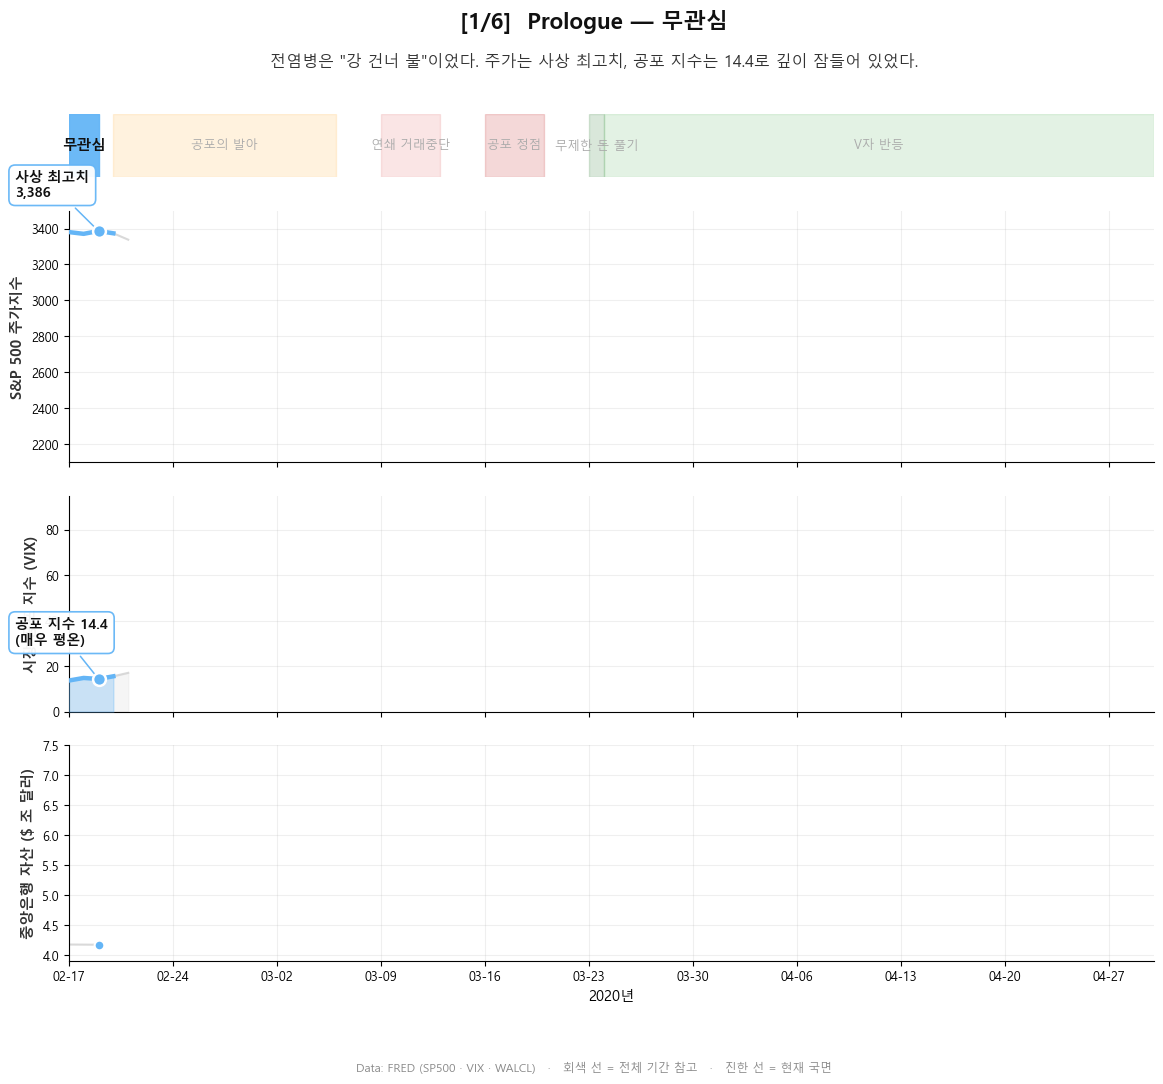

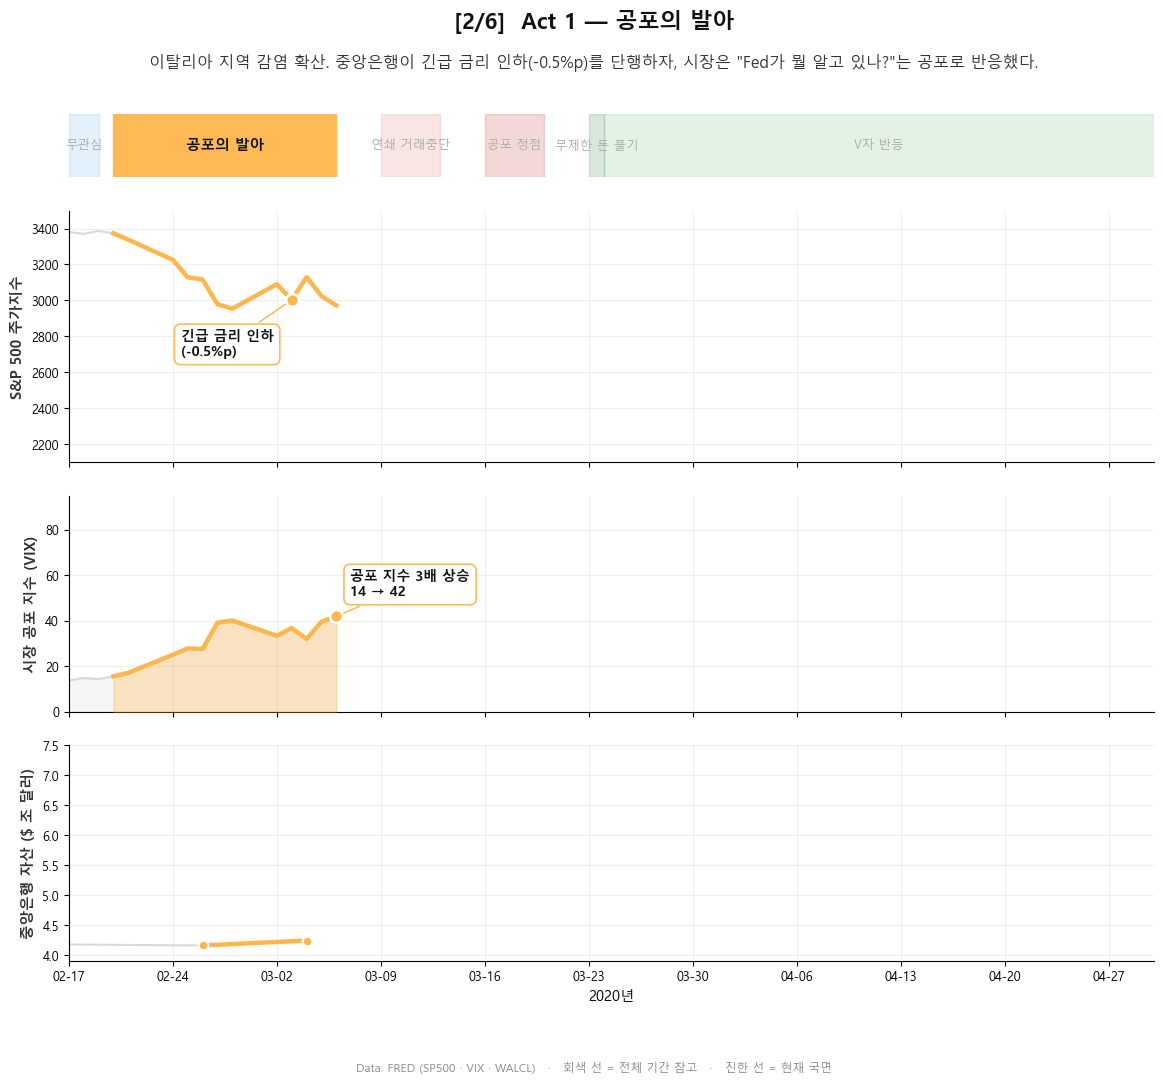

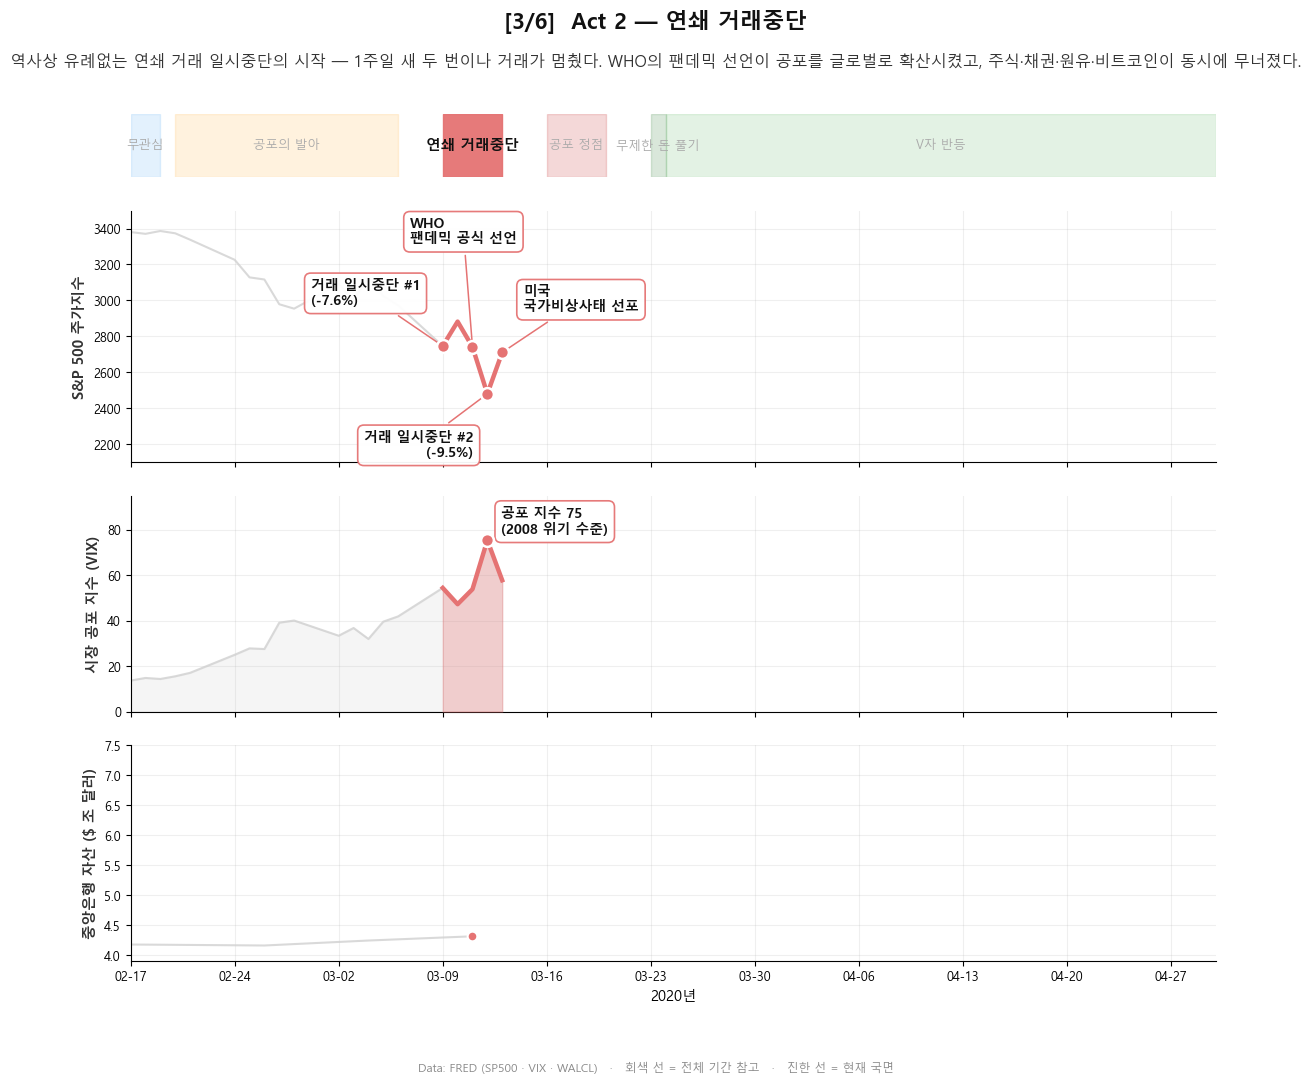

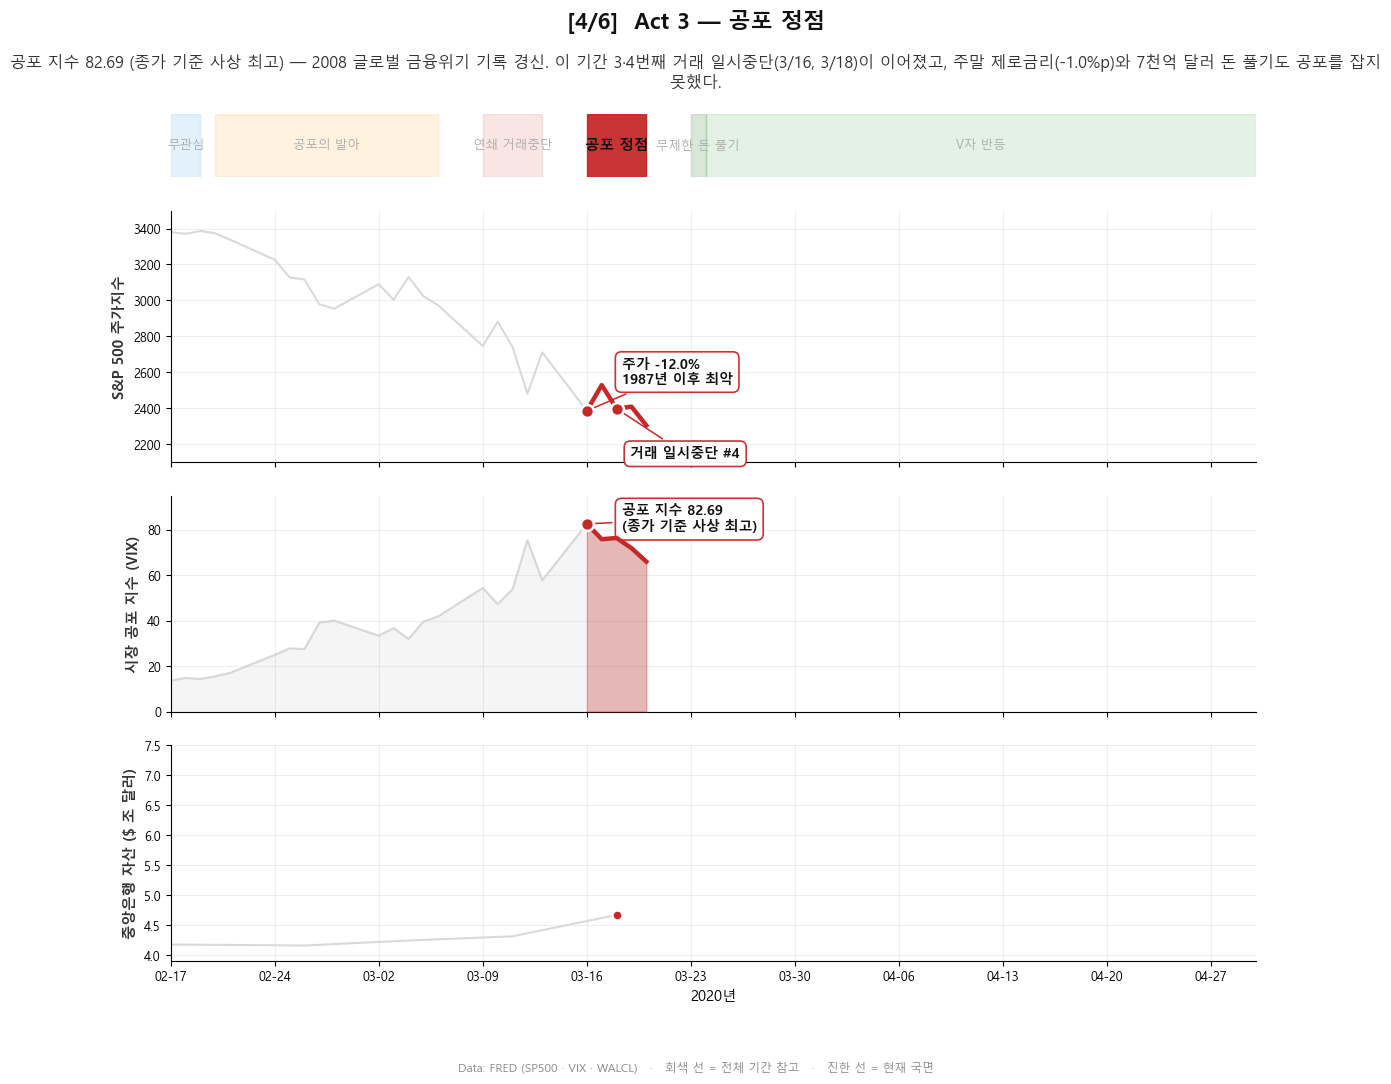

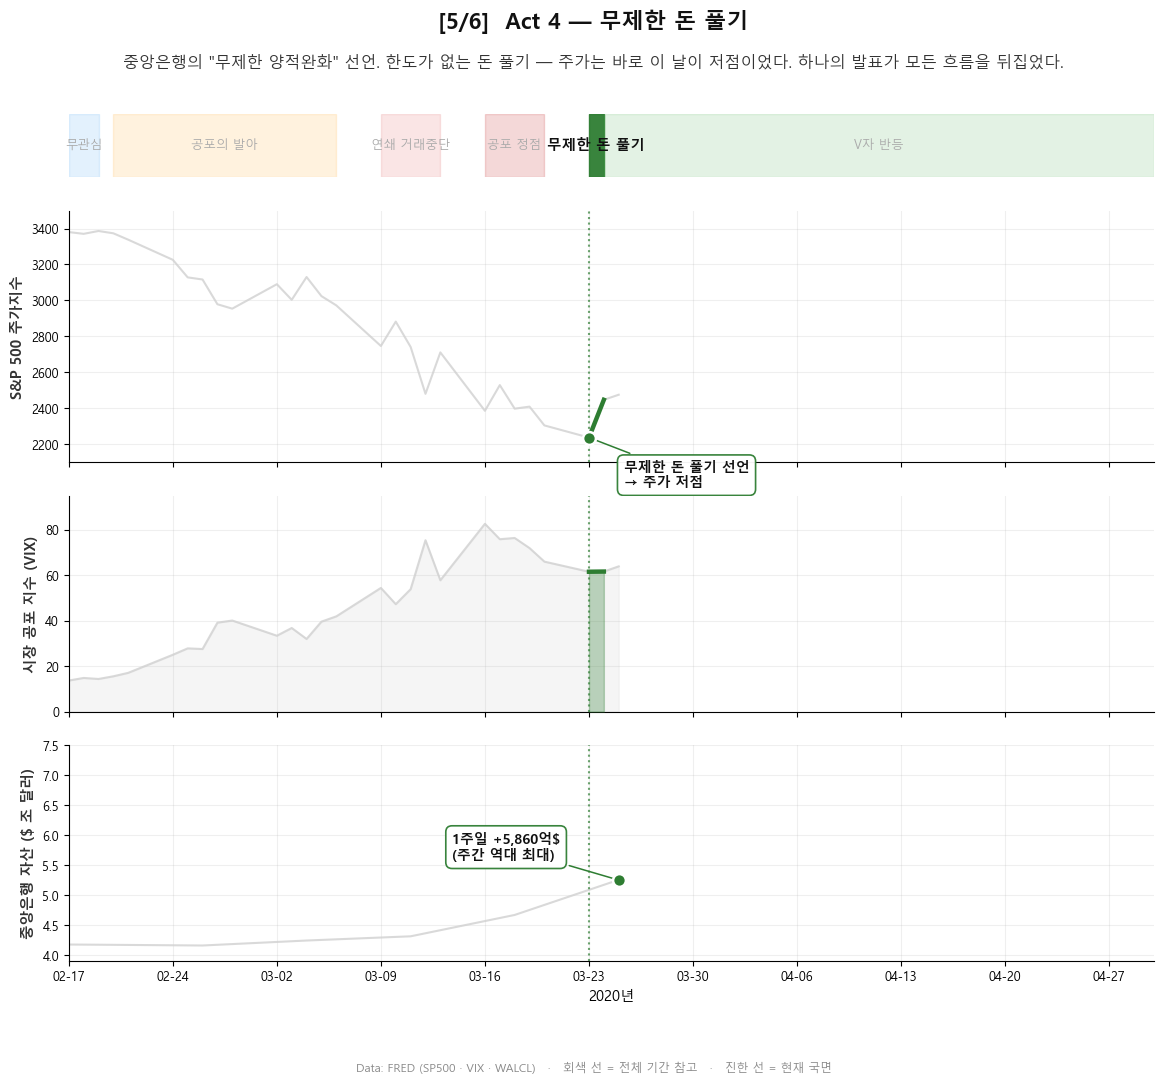

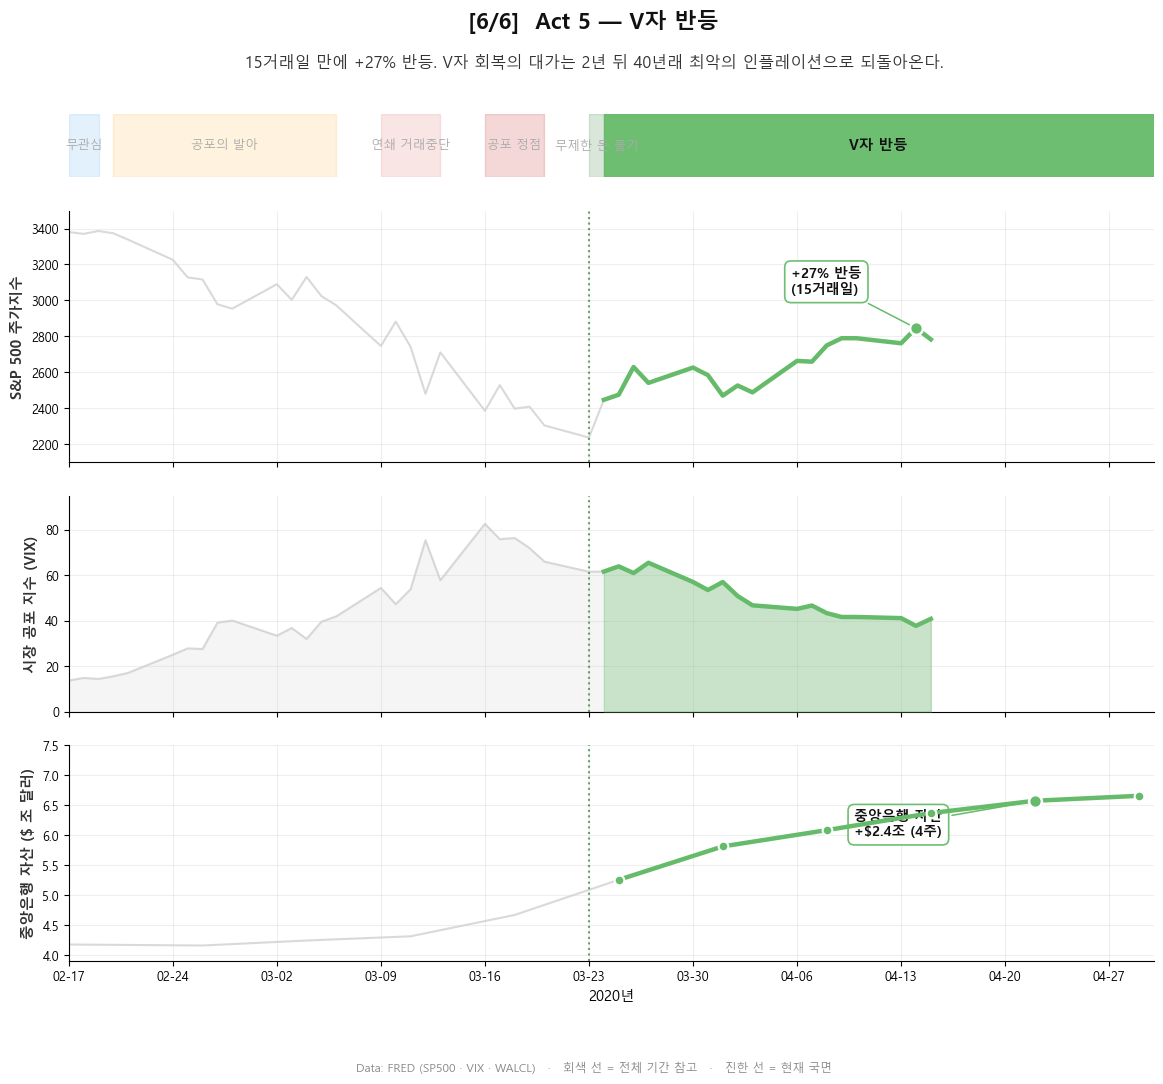


[OK] 저장된 프레임:
  - c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\e01_story\00_prologue.png
  - c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\e01_story\01_act1.png
  - c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\e01_story\02_act2.png
  - c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\e01_story\03_act3.png
  - c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\e01_story\04_act4.png
  - c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\e01_story\05_act5.png


In [20]:
saved = []
for i in range(len(phases)):
    fig, path = draw_frame(i)
    saved.append(path)
    plt.show()

print('\n[OK] 저장된 프레임:')
for p in saved:
    print(f'  - {p}')

## 6. 종합 프레임 — 모든 국면을 한 장으로

Act 4(무제한 돈 풀기) 구간만 하이라이트하고 나머지는 은은하게 처리해, 이 사건의 **변곡점**을 한 눈에 보여준다.

C:\Users\kimch\AppData\Local\Temp\ipykernel_10460\731336145.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.02, 1, 0.92])


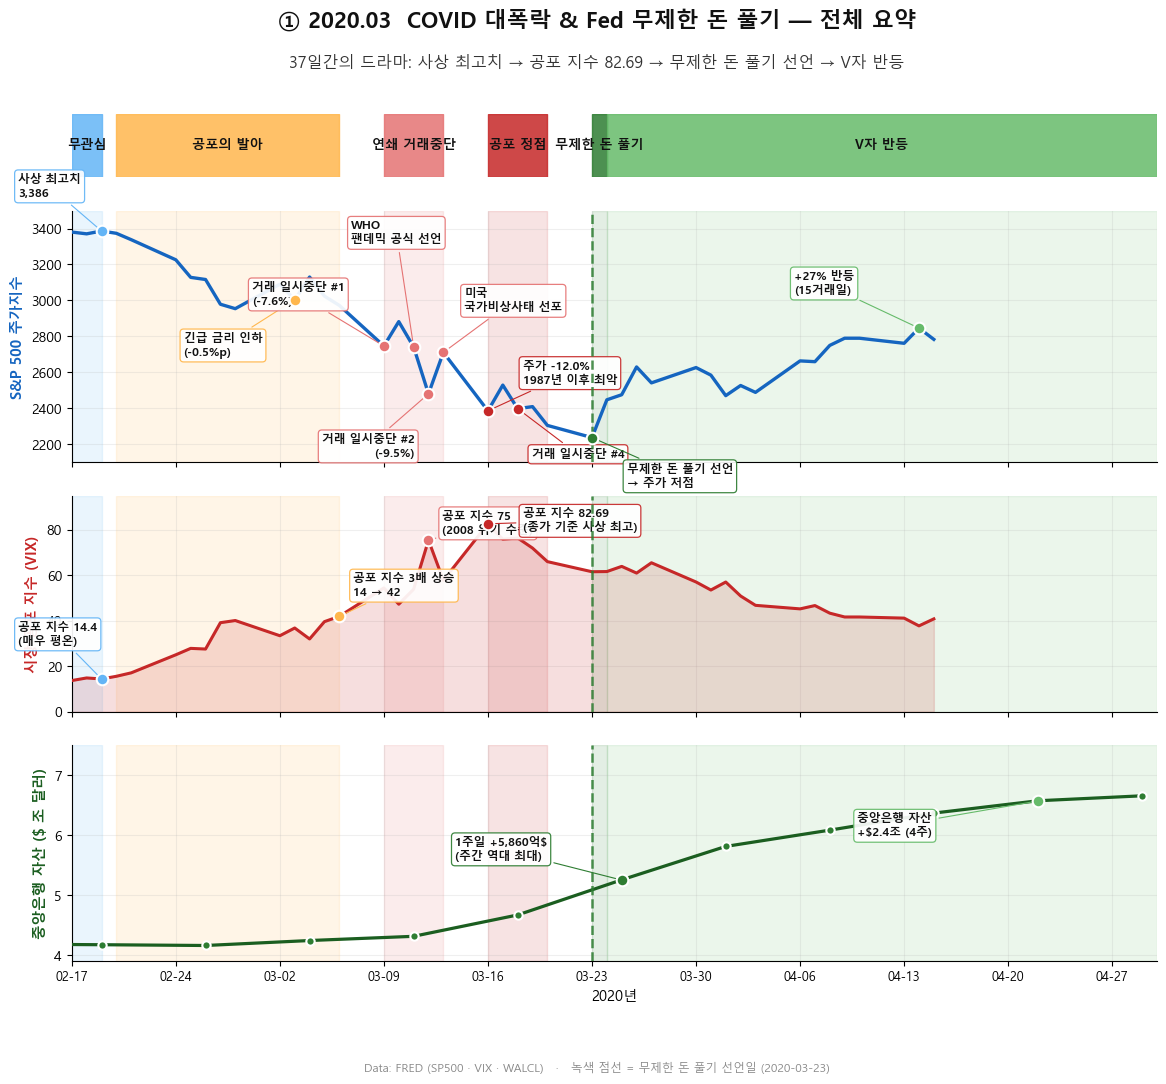


[OK] 종합 프레임: c:\Users\kimch\Desktop\project\pandemic-finance\data\figures\e01_story\99_summary.png


In [21]:
def draw_summary():
    """전체 기간 + 모든 주석을 한 장에 표시 (Act 4 pivot 강조)."""
    fig = plt.figure(figsize=(14, 11))
    gs = fig.add_gridspec(4, 1, height_ratios=[0.35, 1.4, 1.2, 1.2], hspace=0.18)
    ax_rib = fig.add_subplot(gs[0])
    ax_sp  = fig.add_subplot(gs[1], sharex=ax_rib)
    ax_vix = fig.add_subplot(gs[2], sharex=ax_rib)
    ax_fed = fig.add_subplot(gs[3], sharex=ax_rib)

    # Ribbon: 모두 고유 색상
    for p in phases:
        s = pd.Timestamp(p['start']); e = pd.Timestamp(p['end'])
        if s == e:
            e = s + pd.Timedelta(days=1)
        ax_rib.axvspan(s, e, color=p['color'], alpha=0.85)
        short = p['name'].split('—')[1].strip() if '—' in p['name'] else p['name']
        ax_rib.text(s + (e - s) / 2, 0.5, short,
                    ha='center', va='center', fontsize=9.5,
                    fontweight='bold', color='#111')
    ax_rib.set_xlim(XLIM); ax_rib.set_ylim(0, 1); ax_rib.set_yticks([])
    for s in ['top', 'right', 'bottom', 'left']:
        ax_rib.spines[s].set_visible(False)
    ax_rib.tick_params(bottom=False, labelbottom=False)

    # 제목
    fig.suptitle('① 2020.03  COVID 대폭락 & Fed 무제한 돈 풀기 — 전체 요약',
                 fontsize=16, fontweight='bold', y=0.975, color='#111')
    fig.text(0.5, 0.935,
             '37일간의 드라마: 사상 최고치 → 공포 지수 82.69 → 무제한 돈 풀기 선언 → V자 반등',
             ha='center', va='top', fontsize=11.5, color='#333', style='italic')

    # 세 패널: 기본선 짙은 색 + 국면별 배경 음영
    for p in phases:
        s = pd.Timestamp(p['start']); e = pd.Timestamp(p['end'])
        if s == e:
            e = s + pd.Timedelta(days=1)
        for ax in (ax_sp, ax_vix, ax_fed):
            ax.axvspan(s, e, color=p['color'], alpha=0.13, zorder=0)

    ax_sp.plot(event.index, event['SP500'], color='#1565C0', lw=2.4, zorder=3)
    ax_sp.set_ylabel(LABELS['SP500'], fontsize=10.5, fontweight='bold', color='#1565C0')

    ax_vix.plot(event.index, event['VIX'], color='#C62828', lw=2.2, zorder=3)
    ax_vix.fill_between(event.index, event['VIX'], 0, color='#C62828', alpha=0.15, zorder=2)
    ax_vix.set_ylabel(LABELS['VIX'], fontsize=10.5, fontweight='bold', color='#C62828')

    ax_fed.plot(fed_window.index, fed_window['WALCL_T'], color='#1B5E20', lw=2.3,
                marker='o', markersize=6, markerfacecolor='#2E7D32',
                markeredgecolor='white', markeredgewidth=1.5, zorder=3)
    ax_fed.set_ylabel(LABELS['FED'], fontsize=10.5, fontweight='bold', color='#1B5E20')

    for ax in (ax_sp, ax_vix, ax_fed):
        ax.grid(alpha=0.2)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    ax_sp.set_ylim(YLIM_SP)
    ax_vix.set_ylim(YLIM_VIX)
    ax_fed.set_ylim(YLIM_FED)

    # 변곡점 강조
    qe = pd.Timestamp('2020-03-23')
    for ax in (ax_sp, ax_vix, ax_fed):
        ax.axvline(qe, color='#2E7D32', linestyle='--', lw=1.8, alpha=0.85, zorder=4)

    # 모든 hero annotations 표시
    axmap = {'SP500': ax_sp, 'VIX': ax_vix, 'FED': ax_fed}
    for phase in phases:
        for date, target, y, text, (dx, dy), ha in phase['hero_annotations']:
            ax = axmap[target]
            d = pd.Timestamp(date)
            c = phase['color']
            ax.scatter([d], [y], s=70, color=c, zorder=6,
                       edgecolors='white', lw=1.5)
            ax.annotate(text, xy=(d, y), xytext=(dx, dy),
                        textcoords='offset points', fontsize=8.5,
                        fontweight='bold', ha=ha, color='#111',
                        bbox=dict(boxstyle='round,pad=0.3', fc='white',
                                  ec=c, alpha=0.92, lw=0.9),
                        arrowprops=dict(arrowstyle='-', color=c, lw=0.8))

    # x축
    ax_fed.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
    ax_fed.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax_fed.tick_params(axis='x', labelsize=9)
    ax_fed.set_xlabel('2020년', fontsize=10.5)
    for ax in (ax_rib, ax_sp, ax_vix):
        plt.setp(ax.get_xticklabels(), visible=False)

    fig.text(0.5, 0.01,
             'Data: FRED (SP500 · VIX · WALCL)   ·   녹색 점선 = 무제한 돈 풀기 선언일 (2020-03-23)',
             ha='center', fontsize=8.5, color='#888', style='italic')

    plt.tight_layout(rect=[0, 0.02, 1, 0.92])

    out = FIG_DIR / '99_summary.png'
    fig.savefig(out, dpi=140, bbox_inches='tight', facecolor='white')
    return fig, out


fig, path = draw_summary()
plt.show()
print(f'\n[OK] 종합 프레임: {path}')

## 7. 최종 산출물 목록

In [15]:
for f in sorted(FIG_DIR.glob('*.png')):
    print(f'  {f.relative_to(ROOT)}   ({f.stat().st_size // 1024} KB)')

  data\figures\e01_story\00_prologue.png   (105 KB)
  data\figures\e01_story\01_act1.png   (124 KB)
  data\figures\e01_story\02_act2.png   (139 KB)
  data\figures\e01_story\03_act3.png   (139 KB)
  data\figures\e01_story\04_act4.png   (148 KB)
  data\figures\e01_story\05_act5.png   (156 KB)
  data\figures\e01_story\99_summary.png   (236 KB)
